## Parse data

In [1]:
from pathlib import Path

In [5]:
data_directory = Path("/work/magroup/shahula/spatiotemporal_transcriptomics_integration/data/CosMx/ovarian_cancer")

In [6]:
import pandas as pd

cell_metadata = pd.read_csv(data_directory / "meta.csv", index_col=0, skiprows=[1])

In [7]:
cell_metadata

,biosample_id,donor_id,species,species__ontology_label,disease,disease__ontology_label,organ,organ__ontology_label,library_preparation_protocol,library_preparation_protocol__ontology_label,sex,celltypes,cellsubtypes,X_coord,Y_coord
NAME,,,,,,,,,,,,,,,
SMI_T10_F001_c1017,SMI_T10_F001,HGSC1,NCBITaxon:9606,Homo sapiens,MONDO:0005140,ovarian carcinoma,UBERON:0036292,adnexa of uterus,EFO:0009918,smFISH,female,Malignant,Malignant,1493.3500,3151.233
SMI_T10_F001_c102,SMI_T10_F001,HGSC1,NCBITaxon:9606,Homo sapiens,MONDO:0005140,ovarian carcinoma,UBERON:0036292,adnexa of uterus,EFO:0009918,smFISH,female,Malignant,Malignant,2623.2000,3607.450
SMI_T10_F001_c1062,SMI_T10_F001,HGSC1,NCBITaxon:9606,Homo sapiens,MONDO:0005140,ovarian carcinoma,UBERON:0036292,adnexa of uterus,EFO:0009918,smFISH,female,Malignant,Malignant,850.5670,3143.833
SMI_T10_F001_c1064,SMI_T10_F001,HGSC1,NCBITaxon:9606,Homo sapiens,MONDO:0005140,ovarian carcinoma,UBERON:0036292,adnexa of uterus,EFO:0009918,smFISH,female,Malignant,Malignant,3222.7300,3152.586
SMI_T10_F001_c1075,SMI_T10_F001,HGSC1,NCBITaxon:9606,Homo sapiens,MONDO:0005140,ovarian carcinoma,UBERON:0036292,adnexa of uterus,EFO:0009918,smFISH,female,Malignant,Malignant,78.0125,3179.012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SMI_T14_F020_c5758,SMI_T14_F020,HGSC89,NCBITaxon:9606,Homo sapiens,MONDO:0005140,ovarian carcinoma,UBERON:0003688,omentum,EFO:0009918,smFISH,female,TNK.cell,CD4.T.cell.DN,5170.4400,431.900
SMI_T14_F020_c734,SMI_T14_F020,HGSC89,NCBITaxon:9606,Homo sapiens,MONDO:0005140,ovarian carcinoma,UBERON:0003688,omentum,EFO:0009918,smFISH,female,Fibroblast,Fibroblast,768.7000,3188.400
SMI_T14_F020_c875,SMI_T14_F020,HGSC89,NCBITaxon:9606,Homo sapiens,MONDO:0005140,ovarian carcinoma,UBERON:0003688,omentum,EFO:0009918,smFISH,female,Malignant,Malignant,42.5833,3070.350


In [8]:
import pandas as pd
from io import StringIO

In [9]:
sample_metadata = """
profile	dataset	platform	n_cells	median_tpc	mean_tpc	TMA	patients	sites_binary	age	stage	treatment
SMI_T10_F001	Discovery	SMI	5660	205	238.67561837456	TMA 10	HGSC1	Adnexa	58	III	Untreated
SMI_T10_F002	Discovery	SMI	8821	364	393.318671352449	TMA 10	HGSC7	Adnexa	58	III	Untreated
SMI_T10_F003	Discovery	SMI	2881	300	445.154460256851	TMA 10	HGSC8	Adnexa	65	IV	Treated
SMI_T10_F004	Discovery	SMI	3145	286	376.895389507153	TMA 10	HGSC13	Omentum	67	III	Treated
SMI_T10_F005	Discovery	SMI	2187	165	267.202560585273	TMA 10	HGSC15	Adnexa	33	IV	Treated
SMI_T10_F006	Discovery	SMI	5295	384	446.908404154852	TMA 10	HGSC2	Adnexa	36	IV	Untreated
SMI_T10_F007	Discovery	SMI	4117	126	144.580519795968	TMA 10	HGSC6	Omentum	40	III	Treated
SMI_T10_F008	Discovery	SMI	2428	104	122.813838550247	TMA 10	HGSC8	Omentum	65	IV	Treated
SMI_T10_F009	Discovery	SMI	2944	392	458.231317934781	TMA 10	HGSC11	Omentum	54	III	Untreated
SMI_T10_F010	Discovery	SMI	5971	298	360.751465416188	TMA 10	HGSC15	Omentum	33	IV	Treated
SMI_T10_F011	Discovery	SMI	6990	562	620.205007153062	TMA 10	HGSC2	Omentum	36	IV	Untreated
SMI_T10_F012	Discovery	SMI	8874	321	352.719630380898	TMA 10	HGSC6	Adnexa	40	III	Treated
SMI_T10_F013	Discovery	SMI	2765	216	285.206148282095	TMA 10	HGSC9	Adnexa	63	IV	Treated
SMI_T10_F014	Discovery	SMI	5944	395	450.930854643332	TMA 10	HGSC11	Adnexa	54	III	Untreated
SMI_T10_F015	Discovery	SMI	4052	221	287.974333662385	TMA 10	HGSC3	Adnexa	75	IV	Treated
SMI_T10_F016	Discovery	SMI	4218	144	183.137505926981	TMA 10	HGSC4	Adnexa	37	III	Treated
SMI_T10_F018	Discovery	SMI	7549	303	350.855610014566	TMA 10	HGSC10	Omentum	77	IV	Untreated
SMI_T10_F019	Discovery	SMI	10474	267.5	308.97059385143	TMA 10	HGSC4	Omentum	37	III	Treated
SMI_T10_F020	Discovery	SMI	7413	371	429.769998651028	TMA 10	HGSC10	Omentum	77	IV	Untreated
SMI_T10_F021	Discovery	SMI	5338	108	123.439303109779	TMA 10	HGSC6	Omentum	40	III	Treated
SMI_T10_F022	Discovery	SMI	3834	230	277.082159624418	TMA 10	HGSC8	Omentum	65	IV	Treated
SMI_T10_F023	Discovery	SMI	2029	306	391.684573681616	TMA 10	HGSC9	Adnexa	63	IV	Treated
SMI_T10_F024	Discovery	SMI	4085	185	237.821052631577	TMA 10	HGSC3	Adnexa	75	IV	Treated
SMI_T11_F001	Discovery	SMI	2212	109	123.105334538879	TMA 11	HGSC16	Adnexa	66	IV	Untreated
SMI_T11_F002	Discovery	SMI	3267	190	215.897459442913	TMA 11	HGSC28	Adnexa	71	III	Untreated
SMI_T11_F003	Discovery	SMI	3783	238	276.893735130854	TMA 11	HGSC28	Omentum	71	III	Untreated
SMI_T11_F004	Discovery	SMI	8088	196	221.923590504454	TMA 11	HGSC26	Adnexa	59	III	Untreated
SMI_T11_F005	Discovery	SMI	3232	210	256.925123762373	TMA 11	HGSC16	Omentum	66	IV	Untreated
SMI_T11_F006	Discovery	SMI	6437	157	177.635544508309	TMA 11	HGSC25	Omentum	47	III	Untreated
SMI_T11_F007	Discovery	SMI	3701	164	214.155093218047	TMA 11	HGSC29	Adnexa	58	III	Treated
SMI_T11_F008	Discovery	SMI	2967	218	243.226828446243	TMA 11	HGSC22	Adnexa	35	IV	Untreated
SMI_T11_F009	Discovery	SMI	4311	354	394.61006726978	TMA 11	HGSC31	Adnexa	54	III	Untreated
SMI_T11_F010	Discovery	SMI	1161	125	187.785529715762	TMA 11	HGSC19	Adnexa	60	III	Treated
SMI_T11_F011	Discovery	SMI	3876	124	134.389318885449	TMA 11	HGSC25	Adnexa	47	III	Untreated
SMI_T11_F012	Discovery	SMI	2920	194	240.044178082192	TMA 11	HGSC29	Omentum	58	III	Treated
SMI_T11_F013	Discovery	SMI	3507	215	309.626176218986	TMA 11	HGSC21	Adnexa	65	III	Treated
SMI_T11_F014	Discovery	SMI	3245	251	323.743913713404	TMA 11	HGSC84	Omentum	57	III	Treated
SMI_T11_F015	Discovery	SMI	2100	323	427.427619047621	TMA 11	HGSC19	Omentum	60	III	Treated
SMI_T11_F016	Discovery	SMI	3773	255	280.976146302676	TMA 11	HGSC24	Omentum	73	III	Treated
SMI_T11_F017	Discovery	SMI	2028	129	151.964497041421	TMA 11	HGSC18	Adnexa	70	II	Treated
SMI_T11_F018	Discovery	SMI	6177	287	311.186822081918	TMA 11	HGSC20	Adnexa	59	III	Treated
SMI_T11_F019	Discovery	SMI	3136	133	165.879464285713	TMA 11	HGSC24	Adnexa	73	III	Treated
SMI_T11_F020	Discovery	SMI	6266	329	364.458984998404	TMA 11	HGSC17	Adnexa	52	III	Untreated
SMI_T12_F001	Discovery	SMI	5118	203	284.122118014856	TMA 12	HGSC108	Omentum	75	III	Treated
SMI_T12_F002	Discovery	SMI	4466	322	433.263994626066	TMA 12	HGSC109	Omentum	76	IV	Untreated
SMI_T12_F003	Discovery	SMI	6215	294	346.539340305704	TMA 12	HGSC87	Adnexa	58	IV	Treated
SMI_T12_F004	Discovery	SMI	6956	368	387.088700402532	TMA 12	HGSC82	Omentum	51	III	Untreated
SMI_T12_F005	Discovery	SMI	8201	309	347.779051335209	TMA 12	HGSC82	Adnexa	51	III	Untreated
SMI_T12_F006	Discovery	SMI	3675	312	415.397551020412	TMA 12	HGSC108	Adnexa	75	III	Treated
SMI_T12_F007	Discovery	SMI	7039	410	485.76786475353	TMA 12	HGSC109	Adnexa	76	IV	Untreated
SMI_T12_F008	Discovery	SMI	6756	306	352.541888691527	TMA 12	HGSC87	Omentum	58	IV	Treated
SMI_T12_F009	Discovery	SMI	9875	327	367.504810126597	TMA 12	HGSC110	Adnexa	63	I	Untreated
SMI_T12_F011	Discovery	SMI	2893	124	138.321465606636	TMA 12	HGSC112	Omentum	57	III	Untreated
SMI_T12_F012	Discovery	SMI	7226	290	314.258234154447	TMA 12	HGSC113	Adnexa	63	III	Treated
SMI_T12_F013	Discovery	SMI	5203	509	564.656928694986	TMA 12	HGSC114	Adnexa	56	III	Untreated
SMI_T12_F014	Discovery	SMI	879	128	182.296928327646	TMA 12	HGSC111	Adnexa	68	IV	Treated
SMI_T12_F015	Discovery	SMI	7804	302	331.622116863149	TMA 12	HGSC112	Adnexa	57	III	Untreated
SMI_T12_F016	Discovery	SMI	8421	368	409.239401496268	TMA 12	HGSC113	Omentum	63	III	Treated
SMI_T12_F017	Discovery	SMI	5668	376	419.529463655614	NA	HGSCTB	Omentum	NA	NA	NA
SMI_T12_F018	Discovery	SMI	6182	288	337.596408929147	TMA 12	HGSC117	Adnexa	70	III	Untreated
SMI_T12_F019	Discovery	SMI	3059	224	271.622752533506	TMA 12	HGSC111	Omentum	68	IV	Treated
SMI_T12_F020	Discovery	SMI	7519	353	387.899720707537	TMA 12	HGSC112	Omentum	57	III	Untreated
SMI_T13_F001	Discovery	SMI	4262	209	256.099483810414	TMA 13	HGSC33	Omentum	45	III	Untreated
SMI_T13_F002	Discovery	SMI	4961	187	227.002015722634	TMA 13	HGSC46	Adnexa	59	III	Treated
SMI_T13_F003	Discovery	SMI	3226	159	204.763794172348	TMA 13	HGSC46	Omentum	59	III	Treated
SMI_T13_F004	Discovery	SMI	5601	292	333.952865559719	TMA 13	HGSC55	Omentum	59	III	Untreated
SMI_T13_F005	Discovery	SMI	5728	252	283.84444832402	TMA 13	HGSC58	Adnexa	75	III	Untreated
SMI_T13_F007	Discovery	SMI	2271	263	336.232056362838	TMA 13	HGSC42	Omentum	62	III	Treated
SMI_T13_F008	Discovery	SMI	4532	184	304.027140335393	TMA 13	HGSC52	Adnexa	84	III	Treated
SMI_T13_F009	Discovery	SMI	3500	279	320.082000000003	TMA 13	HGSC55	Adnexa	59	III	Untreated
SMI_T13_F010	Discovery	SMI	2371	209	254.761703922394	TMA 13	HGSC58	Omentum	75	III	Untreated
SMI_T13_F011	Discovery	SMI	8340	246	276.762470023988	TMA 13	HGSC35	Adnexa	47	III	Untreated
SMI_T13_F012	Discovery	SMI	2109	131	168.216690374586	TMA 13	HGSC42	Adnexa	62	III	Treated
SMI_T13_F013	Discovery	SMI	2317	148	178.803193785066	TMA 13	HGSC52	Omentum	84	III	Treated
SMI_T13_F014	Discovery	SMI	6717	324	356.858865564988	TMA 13	HGSC56	Omentum	76	III	Untreated
SMI_T13_F015	Discovery	SMI	9348	201	222.502139495082	TMA 13	HGSC35	Omentum	47	III	Untreated
SMI_T13_F016	Discovery	SMI	4366	222	273.140174072375	TMA 13	HGSC38	Omentum	76	III	Untreated
SMI_T13_F017	Discovery	SMI	6479	199	232.319648093847	TMA 13	HGSC54	Adnexa	69	III	Treated
SMI_T13_F018	Discovery	SMI	4984	141	162.312399678973	TMA 13	HGSC56	Adnexa	76	III	Untreated
SMI_T13_F019	Discovery	SMI	3917	196	255.395711003316	TMA 13	HGSC38	Adnexa	76	III	Untreated
SMI_T13_F020	Discovery	SMI	6008	314	348.932756324894	TMA 13	HGSC54	Omentum	69	III	Treated
SMI_T14_F001	Discovery	SMI	3995	197	277.974468085111	TMA 14	HGSC59	Adnexa	67	III	Treated
SMI_T14_F002	Discovery	SMI	7151	389	430.976227101099	TMA 14	HGSC66	Adnexa	70	III	Untreated
SMI_T14_F003	Discovery	SMI	5859	374	461.721624850667	TMA 14	HGSC66	Omentum	70	III	Untreated
SMI_T14_F004	Discovery	SMI	4885	294	345.848106448315	TMA 14	HGSC102	Omentum	59	III	Untreated
SMI_T14_F005	Discovery	SMI	8160	296	334.239828431366	TMA 14	HGSC102	Adnexa	59	III	Untreated
SMI_T14_F006	Discovery	SMI	3298	345.5	510.240448756816	TMA 14	HGSC59	Omentum	67	III	Treated
SMI_T14_F007	Discovery	SMI	6088	429	462.908672798949	TMA 14	HGSC64	Adnexa	76	III	Treated
SMI_T14_F009	Discovery	SMI	1779	175	220.002248454189	TMA 14	HGSC92	Adnexa	68	III	Treated
SMI_T14_F010	Discovery	SMI	3983	127	157.769269394928	TMA 14	HGSC92	Omentum	68	III	Treated
SMI_T14_F011	Discovery	SMI	6340	228	277.019873817031	TMA 14	HGSC61	Adnexa	70	III	Treated
SMI_T14_F012	Discovery	SMI	4943	450	501.103580821363	TMA 14	HGSC64	Omentum	76	III	Treated
SMI_T14_F013	Discovery	SMI	1512	181	223.033068783069	TMA 14	HGSC85	Omentum	56	III	Treated
SMI_T14_F014	Discovery	SMI	4901	228	290.11732299531	TMA 14	HGSC91	Omentum	67	III	Untreated
SMI_T14_F015	Discovery	SMI	5912	466	553.694012178609	TMA 14	HGSC104	Adnexa	77	III	Untreated
SMI_T14_F016	Discovery	SMI	2744	209	288.211734693879	TMA 14	HGSC61	Omentum	70	III	Treated
SMI_T14_F017	Discovery	SMI	3376	276	368.81664691943	TMA 14	HGSC63	Omentum	71	III	Treated
SMI_T14_F018	Discovery	SMI	9961	189	210.500451761873	TMA 14	HGSC89	Adnexa	53	III	Untreated
SMI_T14_F019	Discovery	SMI	3298	205	271.453305033352	TMA 14	HGSC91	Adnexa	67	III	Untreated
SMI_T14_F020	Discovery	SMI	6214	381	406.158191181208	TMA 14	HGSC89	Omentum	53	III	Untreated
"""

In [10]:
csv_file = StringIO(sample_metadata)
sample_metadata = pd.read_csv(csv_file, delimiter='\t', index_col=0)

In [11]:
target_samples = sample_metadata[(sample_metadata["treatment"] == "Untreated") & (sample_metadata["sites_binary"] == "Adnexa")].index

In [12]:
import anndata as ad

In [13]:
dataset = ad.io.read_csv(data_directory / "SCP2640" / "expression" / "cd.csv")

In [19]:
dataset = dataset.T

In [22]:
dataset.obs["batch"] = dataset.obs_names.map(lambda name: "_".join(name.split("_")[:3]))

In [23]:
target_dataset = dataset[dataset.obs["batch"].isin(target_samples)]

In [26]:
cell_metadata["batch"] = dataset.obs_names.map(lambda name: "_".join(name.split("_")[:3]))

In [27]:
target_coordinates = cell_metadata[cell_metadata["batch"].isin(target_samples)][["X_coord", "Y_coord"]]

In [28]:
target_dataset.obs = cell_metadata[cell_metadata["batch"].isin(target_samples)]

In [29]:
target_dataset.obsm["spatial"] = target_coordinates.values

In [30]:
# target_dataset.obs["total_count"] = target_dataset.X.sum(axis=1)

## Popari Preprocessing

In [31]:
import scanpy as sc

In [35]:
import numpy as np

In [33]:
sc.pp.normalize_total(target_dataset)
sc.pp.log1p(target_dataset)

In [29]:
num_genes = 1000
batch_key = "batch"

In [31]:
def joint_highly_variable_genes(merged_dataset: ad.AnnData, num_genes: int, batch_key: str):
    """Jointly determine highly-variable genes for a merged mSRT dataset with multiple batches."""

    gene_index = np.full(len(merged_dataset.var), False)
    datasets = unconcatenate(merged_dataset, batch_key=batch_key)
    for dataset_index, dataset in enumerate(datasets):
        cell_index = merged_dataset.obs[batch_key] == f"{dataset.popari.name}"

        processed_dataset = merged_dataset[cell_index]
        print(len(processed_dataset))

        print(np.multiply(processed_dataset.X, processed_dataset.X).mean(axis=1, dtype=np.float64))

        sc.pp.highly_variable_genes(processed_dataset, n_top_genes=num_genes)

        gene_index |= processed_dataset.var["highly_variable"]

        print(f"Gene set size: {gene_index.sum()}")

    for dataset_index, dataset in enumerate(datasets):
        cell_index = merged_dataset.obs[batch_key] == f"{dataset.popari.name}"

        preprocessed_dataset = merged_dataset[cell_index]

        # min_cells set to 3 as done in moscot
        valid_gene_index, _ = sc.pp.filter_genes(preprocessed_dataset, min_cells=3, inplace=False)

        gene_index &= valid_gene_index
        print(f"Gene set size: {gene_index.sum()}")

    merged_dataset.var["joint_highly_variable"] = gene_index

    return merged_dataset

In [32]:
def split_and_filter_merged(merged_dataset, gene_index_key: str, batch_key: str = "batch"):
    preprocessed_datasets = []
    batch_names = merged_dataset.obs[batch_key].unique()
    datasets = unconcatenate(merged_dataset, batch_key=batch_key)
    for dataset_index, dataset in enumerate(datasets):
        preprocessed_dataset = merged_dataset[merged_dataset.obs[batch_key] == f"{dataset.popari.name}", merged_dataset.var[gene_index_key]]
        
        print(f"Shape before filtering zero-count cells: {preprocessed_dataset.shape}")
        sc.pp.filter_cells(preprocessed_dataset, min_counts=1)

        print(f"Shape after filtering zero-count cells: {preprocessed_dataset.shape}")
        preprocessed_dataset.popari.name = dataset.popari.name

        print("Computing neighbors...")
        preprocessed_dataset.compute_spatial_neighbors()

        print(f"zero-count genes: {(preprocessed_dataset.X.sum(axis=0) == 0).sum()}")

        preprocessed_datasets.append(preprocessed_dataset)

    return preprocessed_datasets

In [36]:
from popari.util import concatenate, unconcatenate

In [34]:
datasets = unconcatenate(target_dataset, batch_key="batch")

In [35]:
merged_dataset = concatenate(datasets)

In [36]:
merged_dataset.X = merged_dataset.X.astype(np.float64)

In [37]:
joint_highly_variable_genes(merged_dataset, num_genes=num_genes, batch_key=batch_key)

5660
[0.12555935 0.1294643  0.15427572 ... 0.15636355 0.15931846 0.17036422]


/work/magroup/shahula/bin/miniconda3/envs/popari_distribution/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:216: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersions']
/work/magroup/shahula/bin/miniconda3/envs/popari_distribution/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:540: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['hvg'] = {'flavor': flavor}
/work/magroup/shahula/bin/miniconda3/envs/popari_distribution/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:216: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False 

Gene set size: 979
8821
[0.14619302 0.14642555 0.15583551 ... 0.17084732 0.17085267 0.1671412 ]
Gene set size: 979
5295
[0.13824085 0.15869726 0.13451194 ... 0.16335419 0.17113637 0.16802781]
Gene set size: 979
5944
[0.13750025 0.14758344 0.13786919 ... 0.16796522 0.16533539 0.16260642]
Gene set size: 979
2212


/work/magroup/shahula/bin/miniconda3/envs/popari_distribution/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:216: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersions']
/work/magroup/shahula/bin/miniconda3/envs/popari_distribution/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:540: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['hvg'] = {'flavor': flavor}
/work/magroup/shahula/bin/miniconda3/envs/popari_distribution/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:216: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False 

[0.15955269 0.16138753 0.17605168 ... 0.1753588  0.1777161  0.17090958]
Gene set size: 979
3267
[0.13225647 0.13950692 0.16510693 ... 0.17021438 0.16974843 0.16506345]
Gene set size: 979
8088
[0.13867283 0.14775073 0.14768471 ... 0.17080549 0.1601345  0.16859076]


...

/work/magroup/shahula/bin/miniconda3/envs/popari_distribution/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:216: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersions']
/work/magroup/shahula/bin/miniconda3/envs/popari_distribution/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:540: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['hvg'] = {'flavor': flavor}
/work/magroup/shahula/bin/miniconda3/envs/popari_distribution/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:216: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False 

Gene set size: 979
3298
[0.14874261 0.16302915 0.14384579 ... 0.16579128 0.16326547 0.16340316]
Gene set size: 979
Gene set size: 979
Gene set size: 979
Gene set size: 979
Gene set size: 979
Gene set size: 979
Gene set size: 979
Gene set size: 979
Gene set size: 979


/work/magroup/shahula/bin/miniconda3/envs/popari_distribution/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:216: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersions']
/work/magroup/shahula/bin/miniconda3/envs/popari_distribution/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:540: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['hvg'] = {'flavor': flavor}


Gene set size: 979
Gene set size: 969
Gene set size: 969
Gene set size: 969
Gene set size: 969
Gene set size: 969
Gene set size: 969
Gene set size: 969
Gene set size: 969
Gene set size: 969
Gene set size: 969
Gene set size: 969
Gene set size: 969
Gene set size: 969
Gene set size: 969
Gene set size: 969
Gene set size: 969
Gene set size: 969
Gene set size: 969


AnnData object with n_obs × n_vars = 161962 × 979
    obs: 'biosample_id', 'donor_id', 'species', 'species__ontology_label', 'disease', 'disease__ontology_label', 'organ', 'organ__ontology_label', 'library_preparation_protocol', 'library_preparation_protocol__ontology_label', 'sex', 'celltypes', 'cellsubtypes', 'X_coord', 'Y_coord', 'batch'
    var: 'joint_highly_variable'
    uns: 'log1p'
    obsm: 'spatial'

In [38]:
# merged_dataset[:, merged_dataset.var["joint_highly_variable"]]

In [39]:
preprocessed_datasets = split_and_filter_merged(merged_dataset, gene_index_key="joint_highly_variable", batch_key=batch_key)

Shape before filtering zero-count cells: (5660, 969)


/work/magroup/shahula/bin/miniconda3/envs/popari_distribution/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['n_counts'] = number


Shape after filtering zero-count cells: (5660, 969)
Computing neighbors...


/work/magroup/shahula/bin/miniconda3/envs/popari_distribution/lib/python3.10/site-packages/anndata/utils.py:349: ExperimentalFeatureWarning: Support for Awkward Arrays is currently experimental. Behavior may change in the future. Please report any issues you may encounter!
  warnings.warn(msg, category, stacklevel=stacklevel)
/work/magroup/shahula/bin/miniconda3/envs/popari_distribution/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['n_counts'] = number


zero-count genes: 0
Shape before filtering zero-count cells: (8821, 969)
Shape after filtering zero-count cells: (8821, 969)
Computing neighbors...
zero-count genes: 0
Shape before filtering zero-count cells: (5295, 969)
Shape after filtering zero-count cells: (5295, 969)
Computing neighbors...


...

zero-count genes: 0
Shape before filtering zero-count cells: (9961, 969)
Shape after filtering zero-count cells: (9961, 969)
Computing neighbors...


/work/magroup/shahula/bin/miniconda3/envs/popari_distribution/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['n_counts'] = number


zero-count genes: 0
Shape before filtering zero-count cells: (3298, 969)
Shape after filtering zero-count cells: (3298, 969)
Computing neighbors...


/work/magroup/shahula/bin/miniconda3/envs/popari_distribution/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['n_counts'] = number


zero-count genes: 0


In [40]:
from popari.plotting import setup_squarish_axes

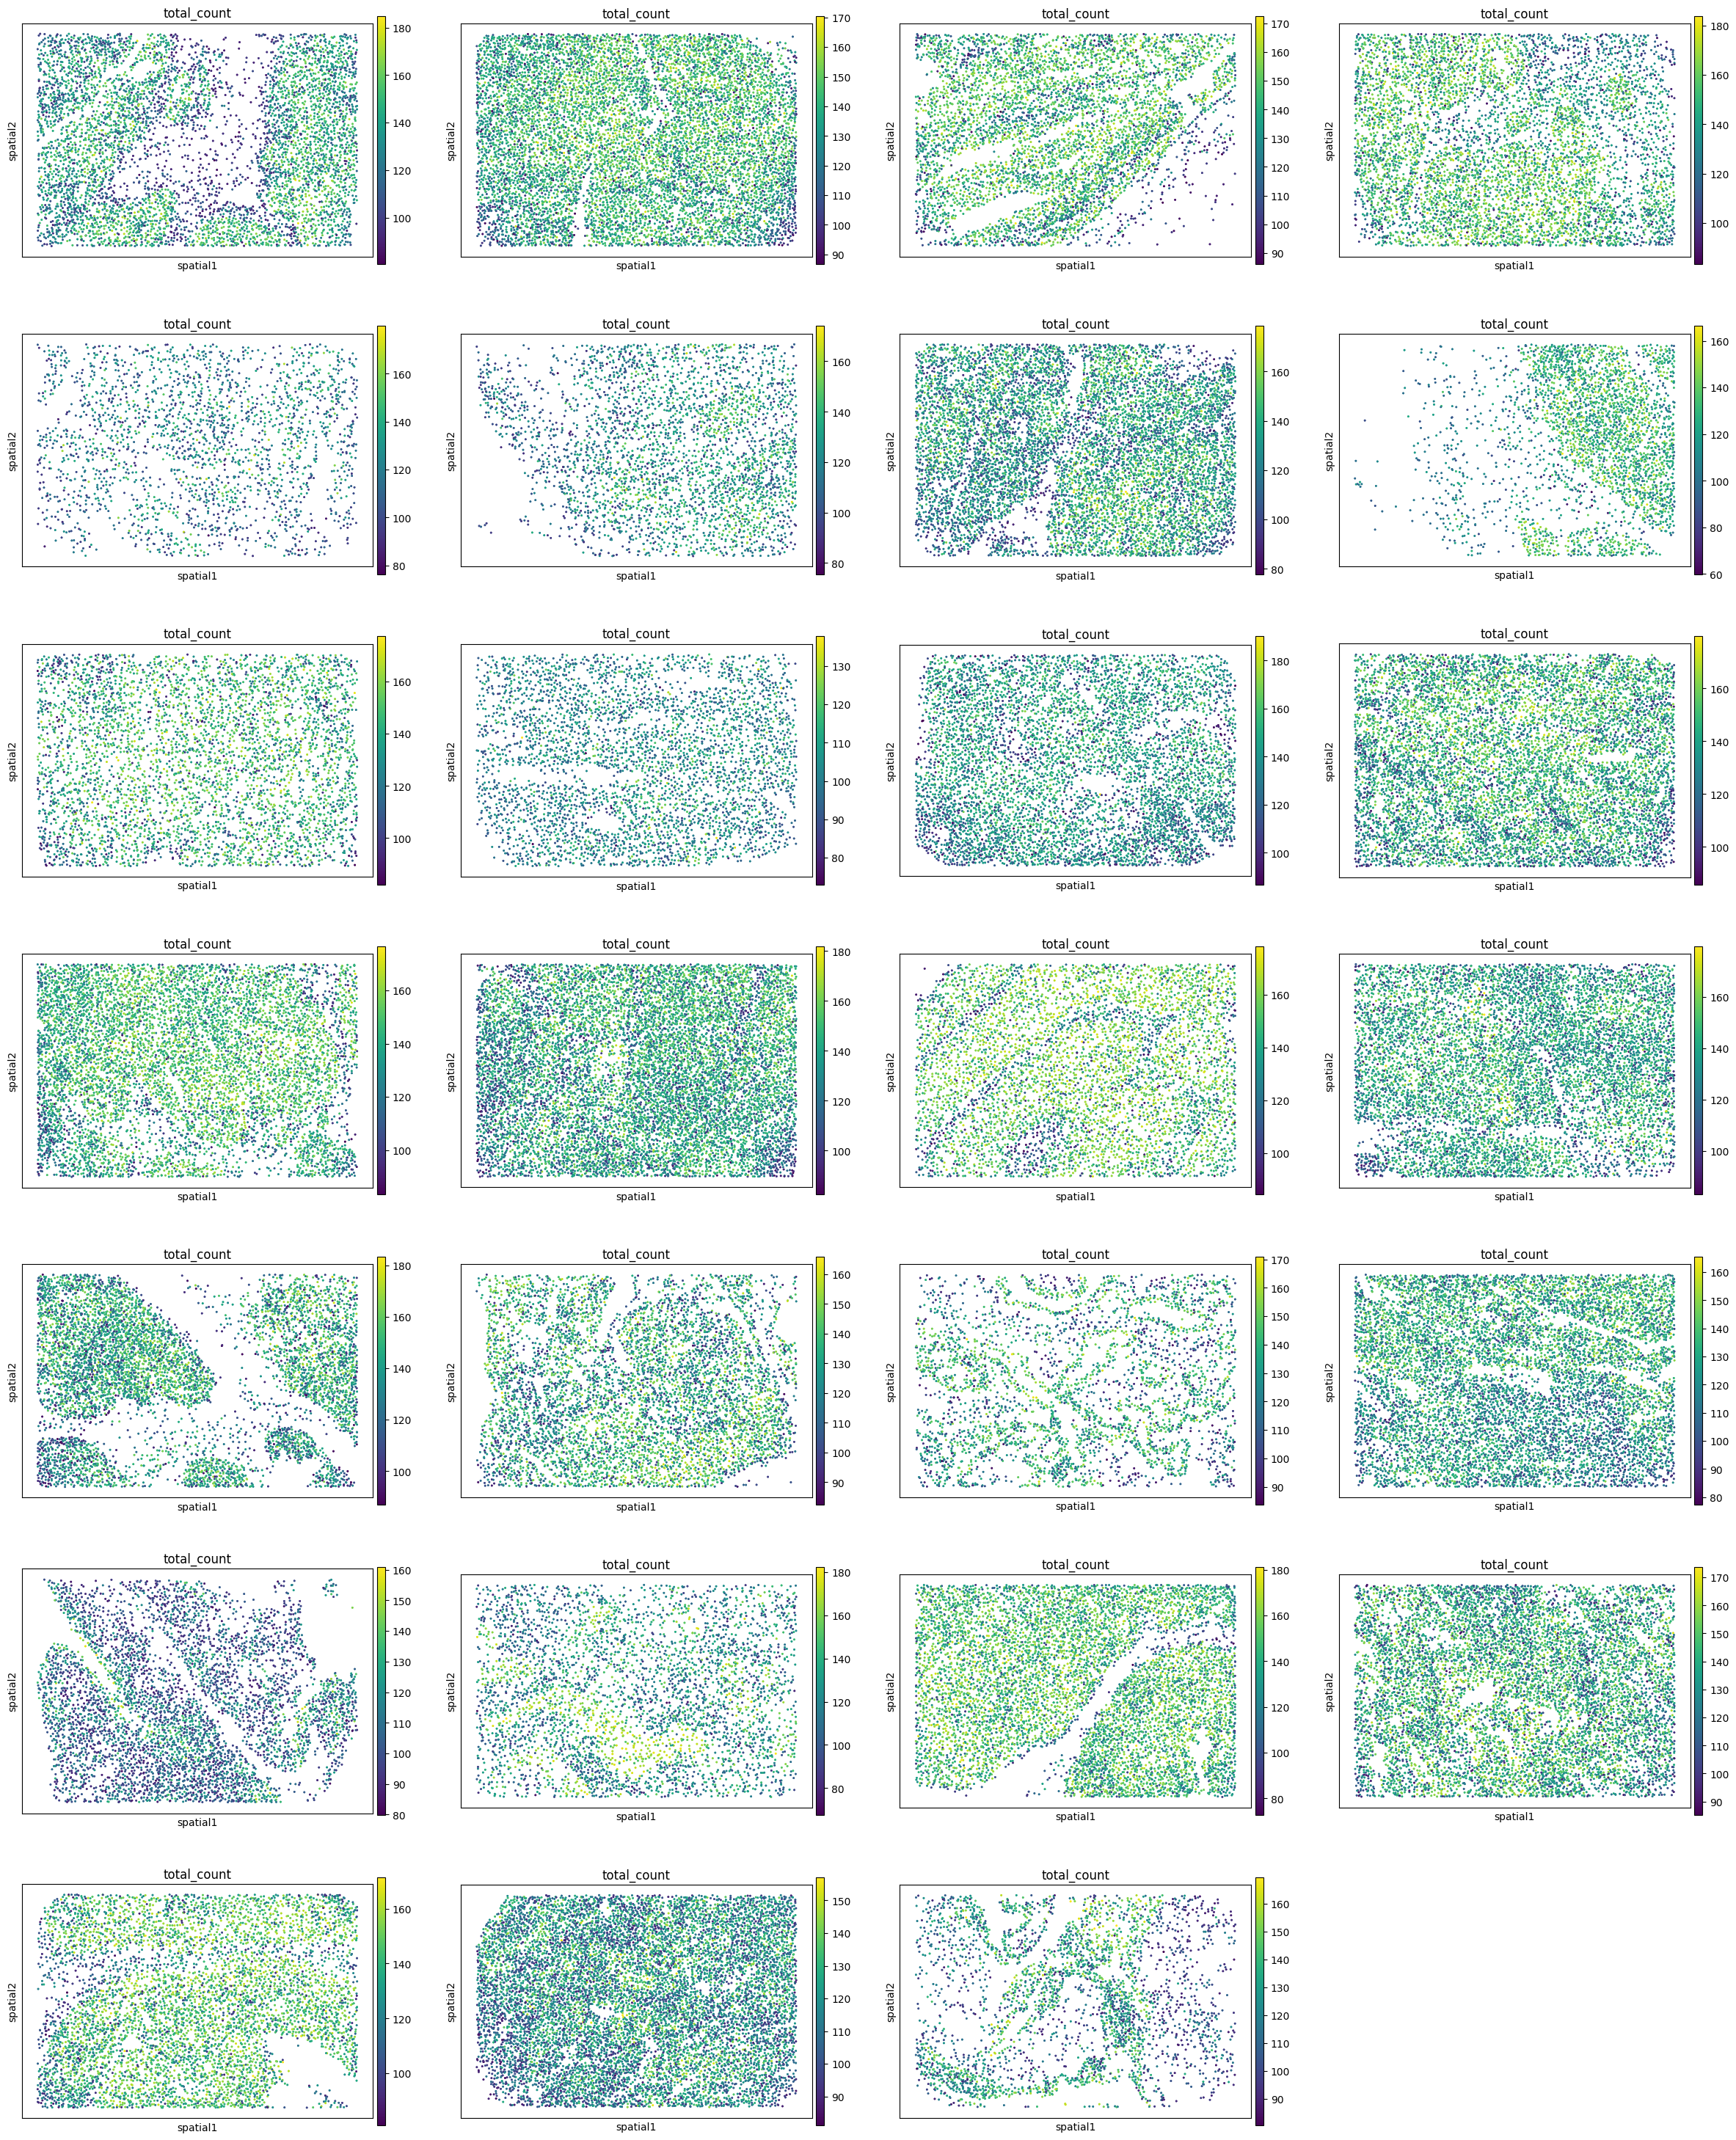

In [44]:
# from popari.util import concatenate
# import squidpy as sq

# sq.pl.spatial_scatter(merged_dataset, library_key="batch", size=4, shape=None, color="total_count")

In [41]:
from popari.preprocessing import pca
from popari.analysis import umap as compute_umap
from popari.plotting import umap as plot_umap

In [42]:
pca(preprocessed_datasets, joint=True)

([AnnData object with n_obs × n_vars = 5660 × 969
      obs: 'biosample_id', 'donor_id', 'species', 'species__ontology_label', 'disease', 'disease__ontology_label', 'organ', 'organ__ontology_label', 'library_preparation_protocol', 'library_preparation_protocol__ontology_label', 'sex', 'celltypes', 'cellsubtypes', 'X_coord', 'Y_coord', 'batch', 'n_counts'
      var: 'joint_highly_variable'
      uns: 'log1p', 'spatial_neighbors', 'pca'
      obsm: 'spatial', 'adjacency_list', 'X_pca'
      varm: 'PCs'
      obsp: 'spatial_connectivities', 'spatial_distances', 'adjacency_matrix',
  AnnData object with n_obs × n_vars = 8821 × 969
      obs: 'biosample_id', 'donor_id', 'species', 'species__ontology_label', 'disease', 'disease__ontology_label', 'organ', 'organ__ontology_label', 'library_preparation_protocol', 'library_preparation_protocol__ontology_label', 'sex', 'celltypes', 'cellsubtypes', 'X_coord', 'Y_coord', 'batch', 'n_counts'
      var: 'joint_highly_variable'
      uns: 'log1p', 'sp

In [43]:
compute_umap(preprocessed_datasets, use_rep="X_pca", joint=True)

([AnnData object with n_obs × n_vars = 5660 × 969
      obs: 'biosample_id', 'donor_id', 'species', 'species__ontology_label', 'disease', 'disease__ontology_label', 'organ', 'organ__ontology_label', 'library_preparation_protocol', 'library_preparation_protocol__ontology_label', 'sex', 'celltypes', 'cellsubtypes', 'X_coord', 'Y_coord', 'batch', 'n_counts'
      var: 'joint_highly_variable'
      uns: 'log1p', 'spatial_neighbors', 'pca', 'umap'
      obsm: 'spatial', 'adjacency_list', 'X_pca', 'X_umap'
      varm: 'PCs'
      obsp: 'spatial_connectivities', 'spatial_distances', 'adjacency_matrix',
  AnnData object with n_obs × n_vars = 8821 × 969
      obs: 'biosample_id', 'donor_id', 'species', 'species__ontology_label', 'disease', 'disease__ontology_label', 'organ', 'organ__ontology_label', 'library_preparation_protocol', 'library_preparation_protocol__ontology_label', 'sex', 'celltypes', 'cellsubtypes', 'X_coord', 'Y_coord', 'batch', 'n_counts'
      var: 'joint_highly_variable'
     

/work/magroup/shahula/bin/miniconda3/envs/popari_distribution/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/work/magroup/shahula/bin/miniconda3/envs/popari_distribution/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


([AnnData object with n_obs × n_vars = 5660 × 969
      obs: 'biosample_id', 'donor_id', 'species', 'species__ontology_label', 'disease', 'disease__ontology_label', 'organ', 'organ__ontology_label', 'library_preparation_protocol', 'library_preparation_protocol__ontology_label', 'sex', 'celltypes', 'cellsubtypes', 'X_coord', 'Y_coord', 'batch', 'n_counts'
      var: 'joint_highly_variable'
      uns: 'log1p', 'spatial_neighbors', 'pca', 'umap'
      obsm: 'spatial', 'adjacency_list', 'X_pca', 'X_umap'
      varm: 'PCs'
      obsp: 'spatial_connectivities', 'spatial_distances', 'adjacency_matrix',
  AnnData object with n_obs × n_vars = 8821 × 969
      obs: 'biosample_id', 'donor_id', 'species', 'species__ontology_label', 'disease', 'disease__ontology_label', 'organ', 'organ__ontology_label', 'library_preparation_protocol', 'library_preparation_protocol__ontology_label', 'sex', 'celltypes', 'cellsubtypes', 'X_coord', 'Y_coord', 'batch', 'n_counts'
      var: 'joint_highly_variable'
     

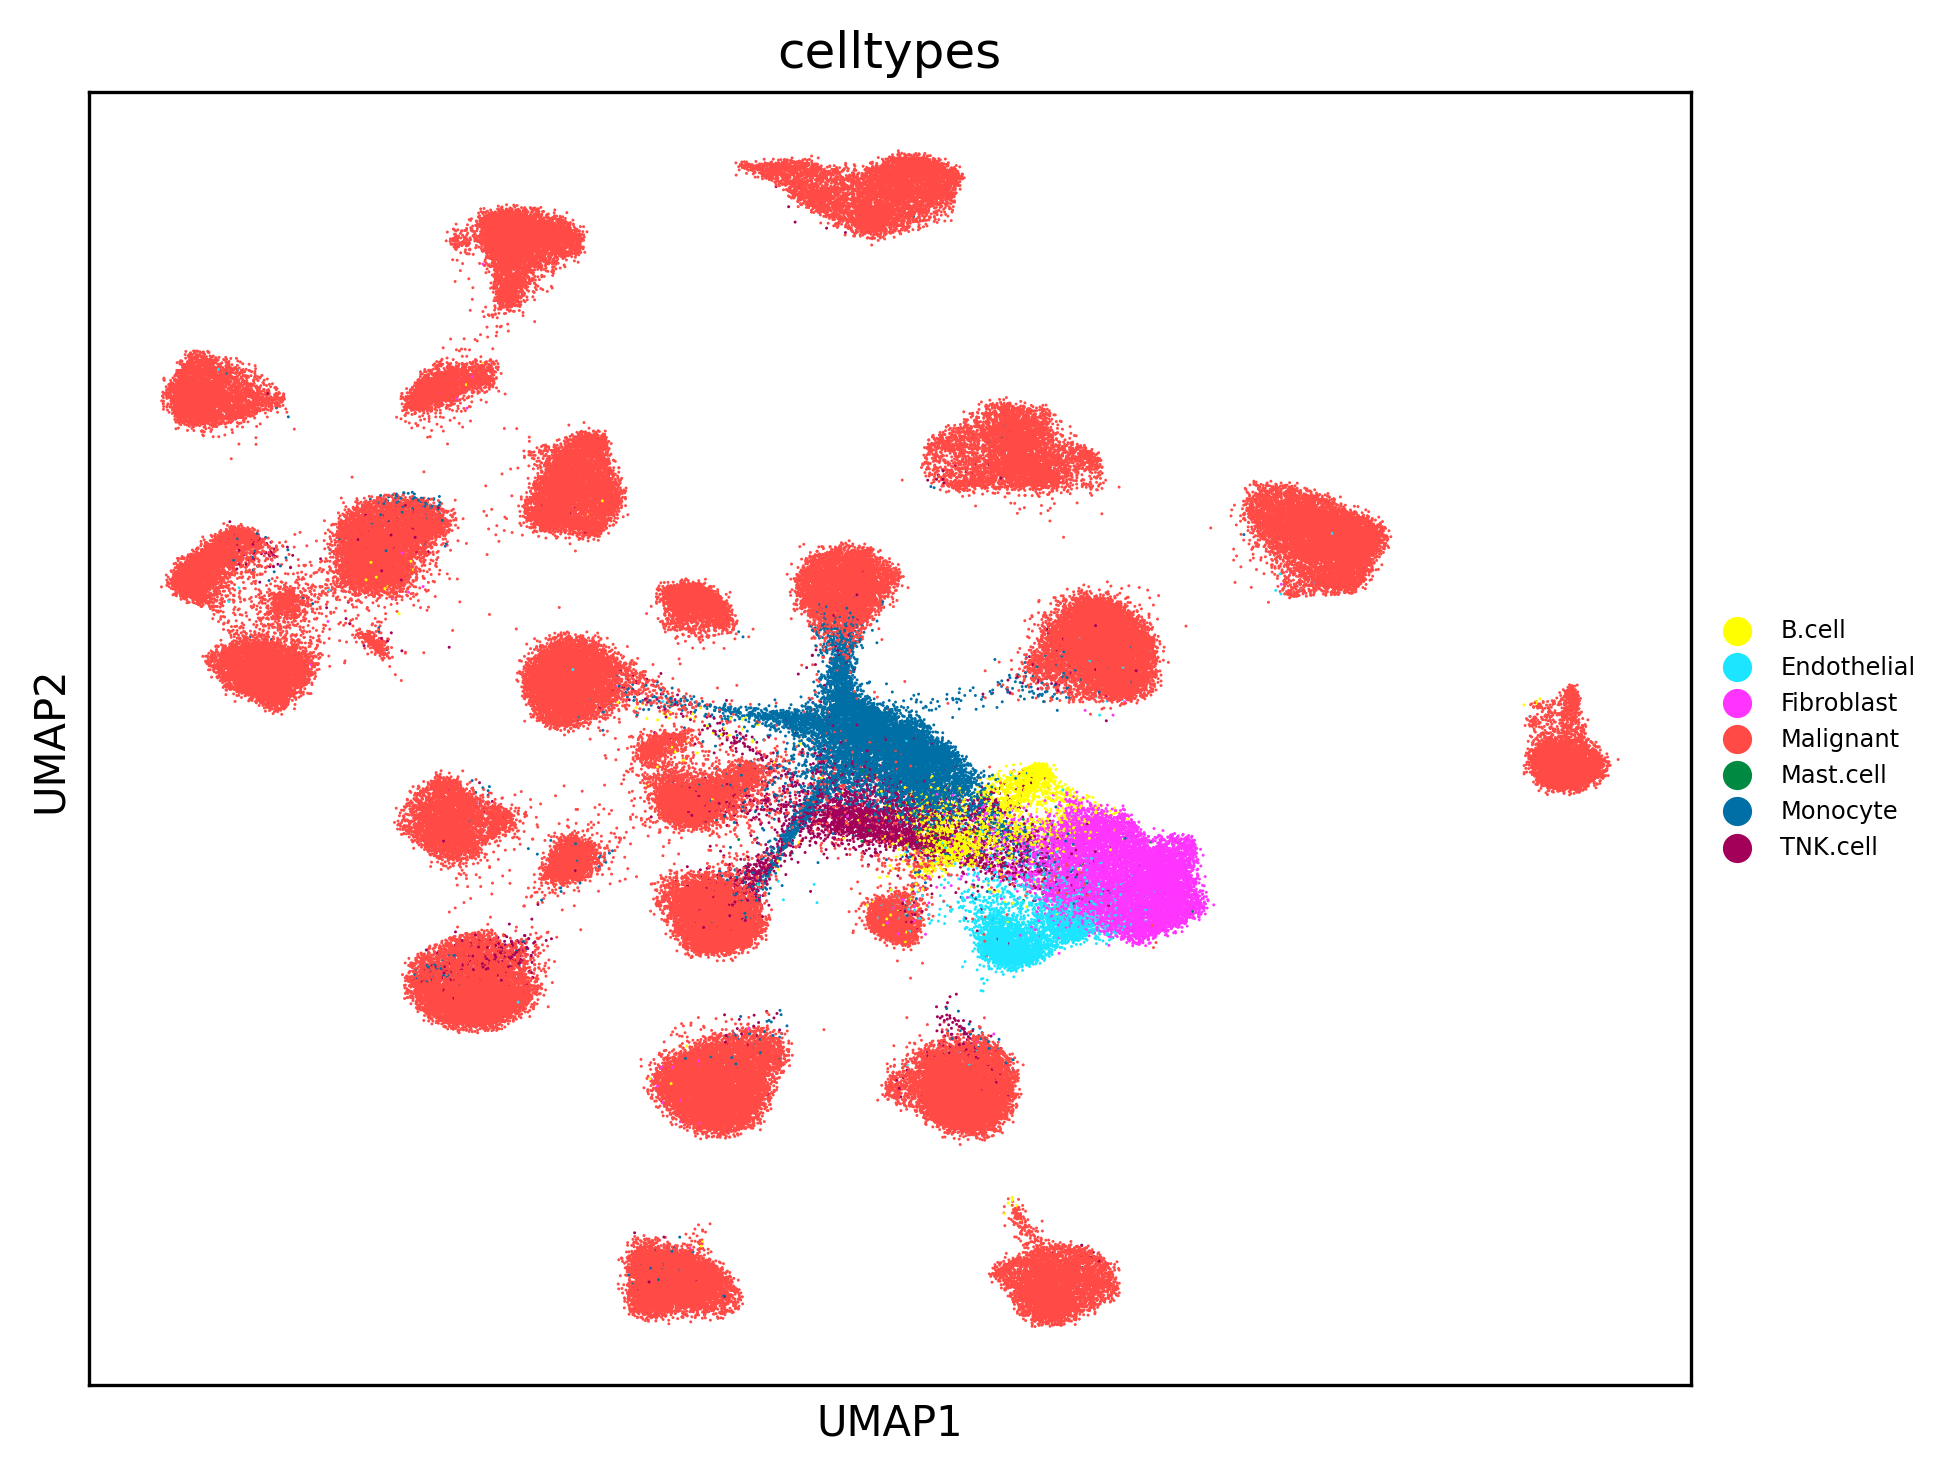

In [49]:
plot_umap(preprocessed_datasets, color="celltypes", size=2, edges=False, joint=True)

In [3]:
from popari.io import save_anndata

In [50]:
save_anndata(data_directory / "processed_dataset.h5ad", preprocessed_datasets)

AnnData object with n_obs × n_vars = 161962 × 969
    obs: 'biosample_id', 'donor_id', 'species', 'species__ontology_label', 'disease', 'disease__ontology_label', 'organ', 'organ__ontology_label', 'library_preparation_protocol', 'library_preparation_protocol__ontology_label', 'sex', 'celltypes', 'cellsubtypes', 'X_coord', 'Y_coord', 'batch', 'n_counts'
    var: 'joint_highly_variable'
    uns: 'log1p', 'spatial_neighbors', 'pca', 'umap', 'adjacency_matrix'
    obsm: 'spatial', 'adjacency_list', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'spatial_connectivities', 'spatial_distances', 'adjacency_matrix'